In [1]:
import numpy as np
import pickle, os, json
from enterprise.signals import anis_coefficients as ac
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
from enterprise_extensions.deterministic import cw_delay
from enterprise import constants as const
# from unmargin_gwb_likelihood import GWBLikelihood as uGWBLikelihood
# from gwb_likelihood import GWBLikelihood
from fakepta import fake_pta
from fakepta.fake_pta import Pulsar, copy_array
from fakepta.fake_pta import make_fake_array
import fakepta.correlated_noises as cn
from fakepta.correlated_noises import hd, dipole, monopole, curn, anisotropic
import matplotlib.pyplot as plt
from astropy.cosmology import WMAP9 as cosmo
from astropy import units as u
import scipy.special as ss
import corner, importlib, inspect, time
from fakepta.fake_pta import plot_pta

In [20]:
G = 6.67 * 1e-11
c = 3 * 1e8
m_dot = 2 * 1e30

seed = 1323
np.random.seed(seed)
log10_toaerr = -7.
npsrs = 1000
Tobs = 10
psrs = make_fake_array(npsrs=npsrs, isotropic=True, Tobs=Tobs, gaps=False, ntoas=500, toaerr=10**log10_toaerr, noisedict={'efac':1, 'log10_tnequad':-12.})
print('Created', npsrs, 'pulsars with', Tobs, 'years of data and log10_toaerr =', log10_toaerr)
#plot_pta(psrs)
#plt.savefig('./pta.png', dpi=300)

for psr in psrs:
    psr.make_ideal()
    psr.add_white_noise()      # ADD WN
print('Added WN with log10_toaerr =', log10_toaerr)

# Add Gaussian GWB
cn.add_common_correlated_noise(psrs, orf='hd', spectrum='powerlaw', log10_A=-14., gamma=13/3)

# Save pickle
#pickle.dump(psrs, open(f'./fake_{npsrs}_psrs_{Tobs}yrs_gauss_gwb_{np.abs(int(log10_toaerr))}WN_nogwb.pkl', 'wb'))
print('Done')

Created 1000 pulsars with 10 years of data and log10_toaerr = -7.0
Added WN with log10_toaerr = -7.0
Done


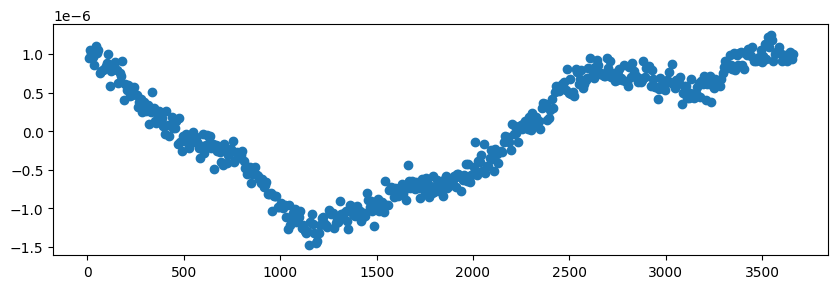

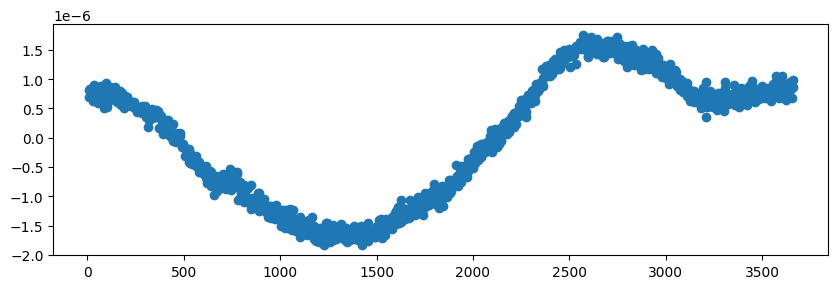

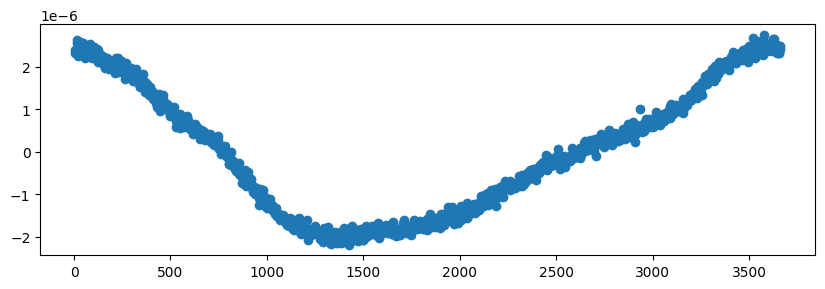

In [21]:
for psr in psrs[0:3]:
    plt.figure(figsize=(10, 3))
    plt.scatter(psr.toas / (3600*24), psr.residuals)
    plt.show()

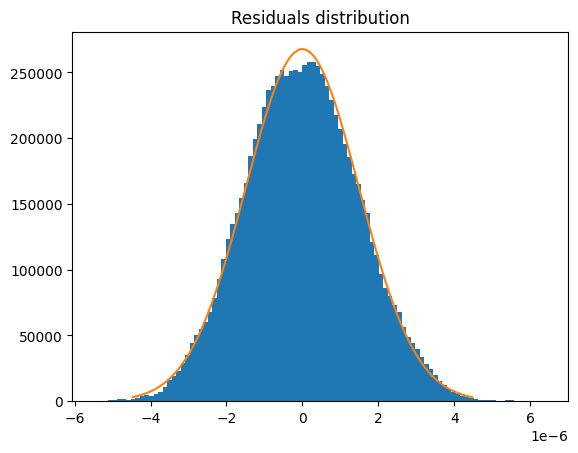

In [22]:
import scipy.stats as stats

res = np.concatenate([psr.residuals for psr in psrs])
mu = np.mean(res)
sigma = np.std(res)

x = np.linspace(mu-3*sigma, mu+3*sigma, 1000)

plt.title('Residuals distribution')
plt.hist(res, bins=100, density=True)
plt.plot(x, stats.norm.pdf(x, mu, sigma))
plt.show()

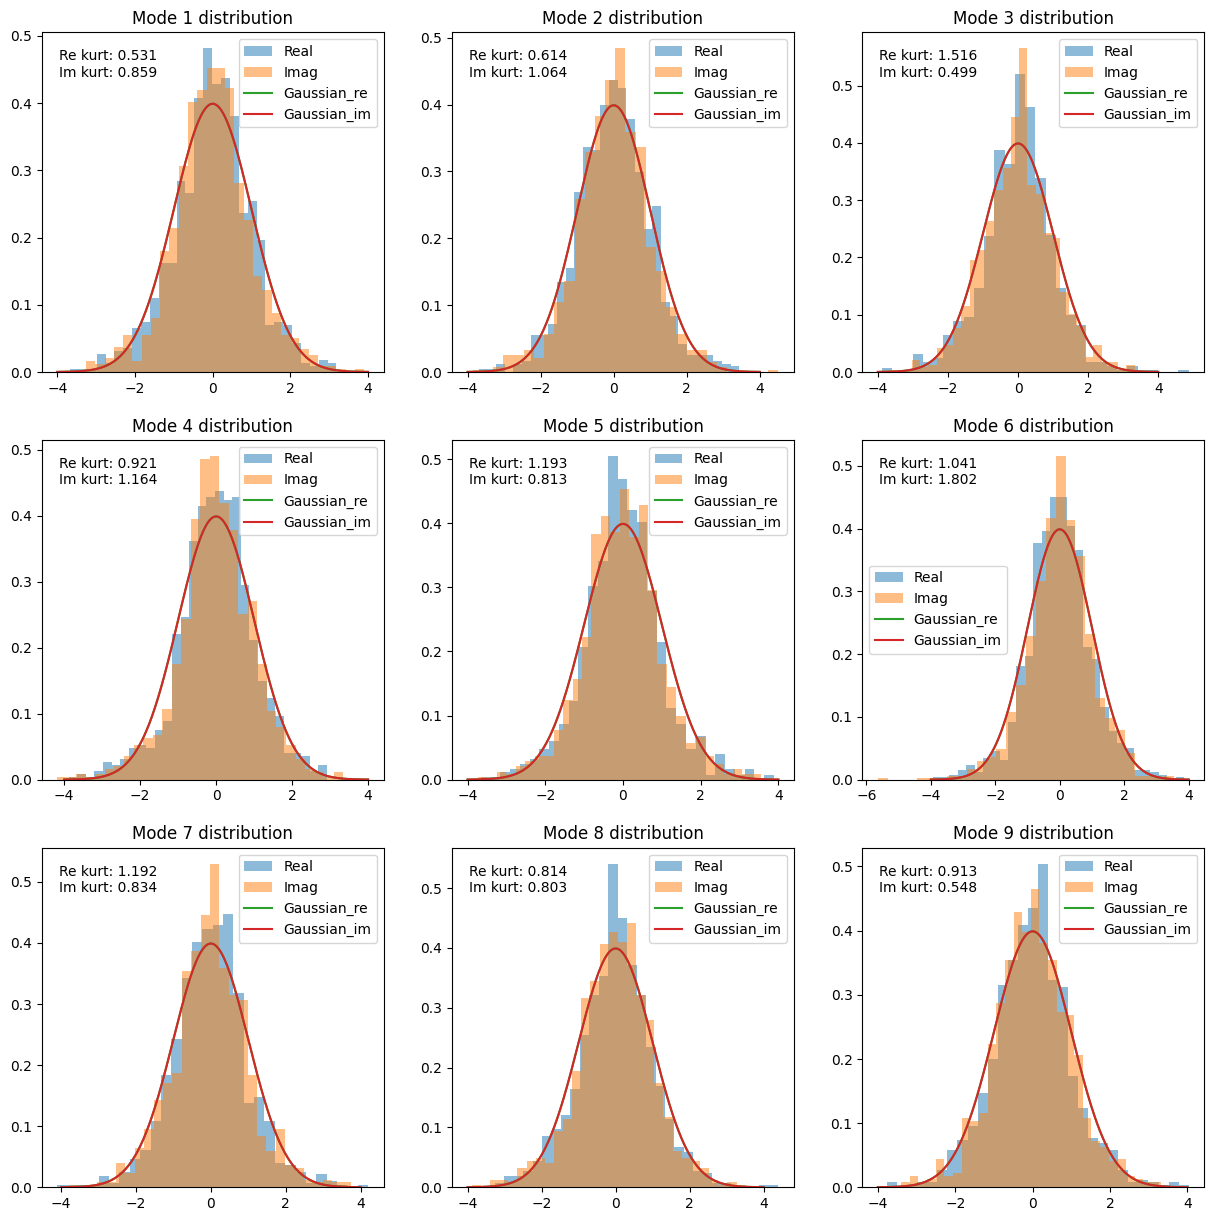

In [23]:
from numpy.fft import rfft
import scipy.stats as stats

fig, ax = plt.subplots(3, 3, figsize=(15, 15))

nmodes = 9

kurt_re = []
kurt_im = []

for mode_idx in range(nmodes):

    vals_re = []
    vals_im = []

    for psr in psrs:

        r = psr.residuals
        fft = rfft(r)
        vals_re.append(np.real(fft[mode_idx+1]))
        vals_im.append(np.imag(fft[mode_idx+1]))

    vals_re = np.array(vals_re)
    vals_im = np.array(vals_im)

    # normalize each mode separately
    vals_re = (vals_re - np.mean(vals_re)) / np.std(vals_re)
    vals_im = (vals_im - np.mean(vals_im)) / np.std(vals_im)

    ax[mode_idx//3, mode_idx%3].set_title(f'Mode {mode_idx+1} distribution')
    ax[mode_idx//3, mode_idx%3].hist(vals_re, bins=30, density=True, alpha=0.5, label='Real')
    ax[mode_idx//3, mode_idx%3].hist(vals_im, bins=30, density=True, alpha=0.5, label='Imag')

    x = np.linspace(-4, 4, 1000)
    ax[mode_idx//3, mode_idx%3].plot(x, stats.norm.pdf(x, 0, 1), label='Gaussian_re')
    ax[mode_idx//3, mode_idx%3].plot(x, stats.norm.pdf(x, 0, 1), label='Gaussian_im')
    ax[mode_idx//3, mode_idx%3].legend()
    kurt_re.append(stats.kurtosis(vals_re))
    kurt_im.append(stats.kurtosis(vals_im))
    ax[mode_idx//3, mode_idx%3].text(0.05, 0.95,f'Re kurt: {kurt_re[-1]:.3f}\nIm kurt: {kurt_im[-1]:.3f}',transform=ax[mode_idx//3, mode_idx%3].transAxes,va='top')

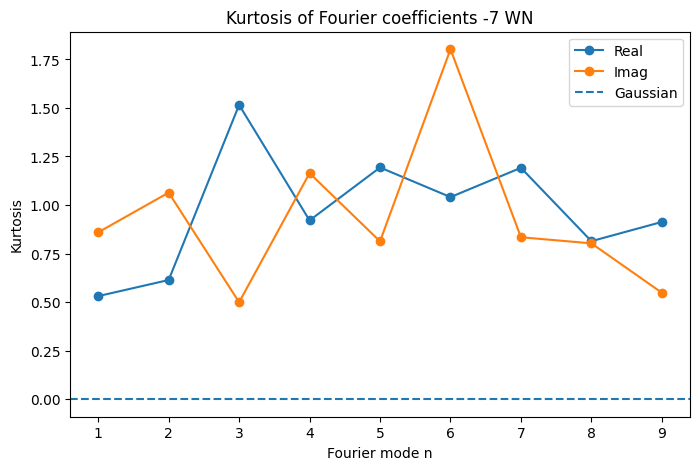

In [24]:
modes = np.arange(1, nmodes + 1)

plt.figure(figsize=(8,5))
plt.plot(modes, kurt_re, marker='o', label='Real')
plt.plot(modes, kurt_im, marker='o', label='Imag')
plt.axhline(0, linestyle='--', label='Gaussian')
plt.xlabel("Fourier mode n")
plt.ylabel("Kurtosis")
plt.title(f"Kurtosis of Fourier coefficients -{np.abs(int(log10_toaerr))} WN")
plt.legend()
#plt.savefig(f'./kurtosis_{np.abs(int(log10_toaerr))}WN_nogwb.png', dpi=300)